## **Data Visualization**

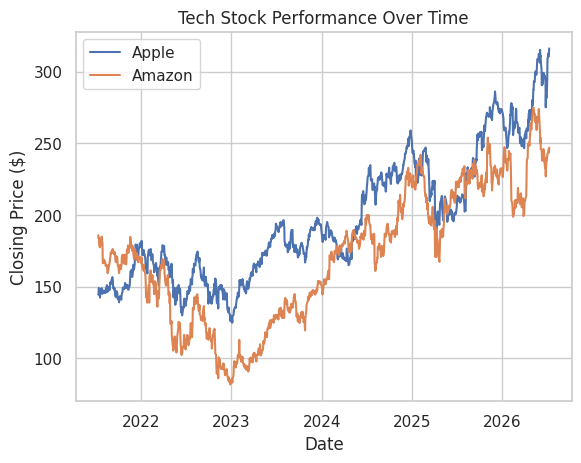

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

df = pd.read_csv("StockDataCleaned_Data.csv")

# 1. Clean the Data: Remove the '$' signs and convert to numbers
df['AAPL Close'] = df['AAPL Close'].replace(r'[\$,]', '', regex=True).astype(float)
df['AMZN Close'] = df['AMZN Close'].replace(r'[\$,]', '', regex=True).astype(float)

# 2. Convert Date column to actual datetime objects for proper spacing on the X-axis
df['Date'] = pd.to_datetime(df['Date'])

# 3. Plot multiple stocks
sns.lineplot(data=df, x='Date', y='AAPL Close', label='Apple')
sns.lineplot(data=df, x='Date', y='AMZN Close', label='Amazon')

plt.title("Tech Stock Performance Over Time")
plt.ylabel("Closing Price ($)")
plt.show()

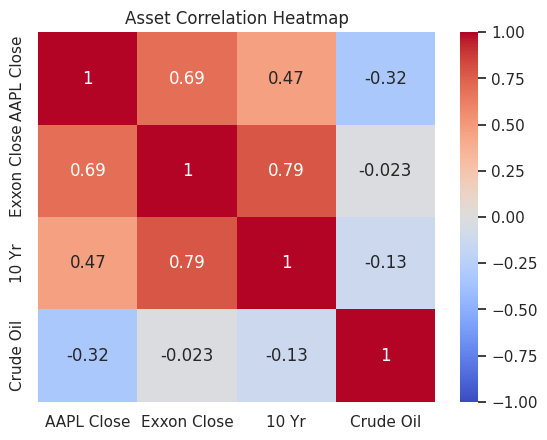

In [39]:
# Clean all the relevant columns first, then calculate correlation
columns_to_compare = ['AAPL Close', 'Exxon Close', '10 Yr', 'Crude Oil']

for col in columns_to_compare:
    if df[col].dtype == 'O': # If it's a string (Object), clean the dollar signs
        df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)

# Calculate the correlation matrix
corr_matrix = df[columns_to_compare].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Asset Correlation Heatmap")
plt.show()

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Ensure this path is correct for your environment
file_path = '/content/StockDataCleaned_Data.csv'

# Read and Sort
df = pd.read_csv(file_path)
df = df.sort_values(by='Date', ascending=True).reset_index(drop=True)

# Separate Date from features
dates = df['Date']
features = df.drop(columns=['Date'])

# Clean formatting
for col in features.columns:
    if features[col].dtype == 'object' or features[col].dtype == 'string':
        features[col] = features[col].replace(r'[\$,]', '', regex=True).astype(float)

# --- DEFINE YOUR TARGET VARIABLE ---
# Assuming 'Close' is at index 0. Update this if your target is in a different column!
target_idx = 0

split_idx = int(len(features) * 0.65)
train_data = features.iloc[:split_idx]
test_data = features.iloc[split_idx:]

# Fit scaler
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Impute NaNs
for i in range(train_scaled.shape[1]):
    col_mean_train = np.nanmean(train_scaled[:, i])
    if np.isnan(col_mean_train): col_mean_train = 0.0
    train_scaled[np.isnan(train_scaled[:, i]), i] = col_mean_train

for i in range(test_scaled.shape[1]):
    col_mean_test = np.nanmean(test_scaled[:, i])
    if np.isnan(col_mean_test): col_mean_test = 0.0
    test_scaled[np.isnan(test_scaled[:, i]), i] = col_mean_test

# Sequence Generation - MODIFIED to output only the target index
def create_seq2seq_windows(data, target_index, lookback=30, horizon=30):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        window_x = data[i : (i + lookback), :]
        # Slice only the specific target feature
        window_y = data[(i + lookback) : (i + lookback + horizon), target_index]
        X.append(window_x)
        y.append(window_y)

    # Reshape y to (Samples, Time Steps, 1) to match TimeDistributed(Dense(1))
    return np.array(X), np.array(y).reshape(-1, horizon, 1)

X_train, y_train = create_seq2seq_windows(train_scaled, target_index=target_idx)
X_test, y_test = create_seq2seq_windows(test_scaled, target_index=target_idx)

print(f"X_train shape: {X_train.shape} -> (Samples, Time Steps, Features)")
print(f"y_train shape: {y_train.shape} -> (Samples, Time Steps, Targets)")


X_train shape: (756, 30, 42) -> (Samples, Time Steps, Features)
y_train shape: (756, 30, 1) -> (Samples, Time Steps, Targets)


In [54]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='keras')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, RepeatVector, TimeDistributed, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

n_timesteps_in = X_train.shape[1]
n_features = X_train.shape[2]
n_timesteps_out = y_train.shape[1]
n_targets = y_train.shape[2] # This is now exactly 1

model = Sequential()
model.add(Input(shape=(n_timesteps_in, n_features))) # Fixes the Keras Sequential warning

# Encoder - CNN
model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')) # Increased filters
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3)) # Added Dropout
model.add(Conv1D(filters=256, kernel_size=3, activation='relu', padding='same')) # Increased filters
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3)) # Added Dropout

# Encoder - LSTM
model.add(LSTM(256, activation='tanh', return_sequences=True)) # Increased units
model.add(Dropout(0.3)) # Added Dropout
model.add(LSTM(256, activation='tanh', return_sequences=False)) # Changed to return_sequences=False for RepeatVector
model.add(Dropout(0.3)) # Added Dropout

# Bridge (Repeats the last LSTM's output for each output timestep)
model.add(RepeatVector(n_timesteps_out))

# Decoder - LSTM
model.add(LSTM(256, activation='tanh', return_sequences=True)) # Increased units
model.add(Dropout(0.3)) # Added Dropout
model.add(LSTM(256, activation='tanh', return_sequences=True)) # Increased units
model.add(Dropout(0.3)) # Added Dropout

# Added a Dense layer before the output for better feature mapping
model.add(TimeDistributed(Dense(128, activation='relu')))
model.add(Dropout(0.3))

# Output Layer
model.add(TimeDistributed(Dense(n_targets)))

optimizer = Adam(learning_rate=0.001, clipvalue=1.0)
model.compile(optimizer=optimizer, loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Starting model training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Starting model training...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 570ms/step - loss: 0.0869 - val_loss: 0.0711
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 501ms/step - loss: 0.0580 - val_loss: 0.0647
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 544ms/step - loss: 0.0555 - val_loss: 0.0665
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 551ms/step - loss: 0.0543 - val_loss: 0.0625
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 506ms/step - loss: 0.0534 - val_loss: 0.0634
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 496ms/step - loss: 0.0527 - val_loss: 0.0621
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 503ms/step - loss: 0.0523 - val_loss: 0.0611
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 501ms/step - loss: 0.0521 - val_loss: 0.0619
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 459ms/step - loss: 0.0518 - val_loss: 0.0610
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 499ms/step - loss: 0.0519 - val_loss: 0.0606
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 500ms/step - loss: 0.0518 - val_loss: 0.0602
Epoch 12/50
24

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 359ms/step
Average Test RMSE: 44.4694
Average Test MAE:  38.7822


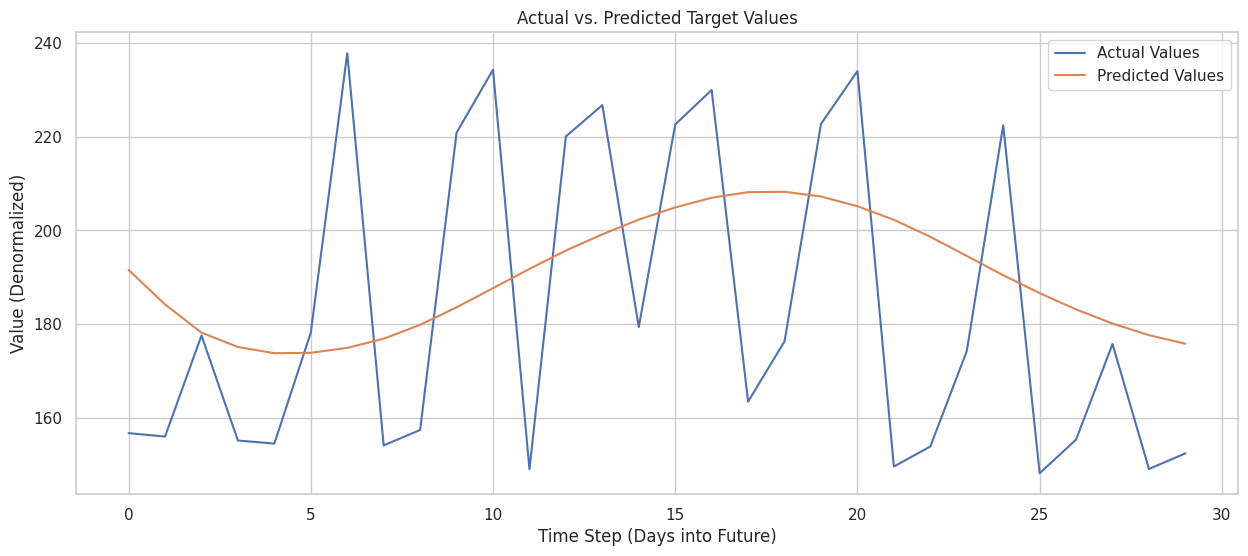

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

predictions_scaled = model.predict(X_test)

# Helper function to inverse transform a single column
def denormalize_single_feature(scaled_data, target_index, base_scaler, total_features):
    # Create an empty matrix of shape (Total Elements, 42 features)
    dummy = np.zeros((scaled_data.size, total_features))
    # Inject our scaled predictions into the specific target column
    dummy[:, target_index] = scaled_data.flatten()
    # Inverse transform the entire matrix
    dummy_inv = base_scaler.inverse_transform(dummy)
    # Extract only the target column and reshape to original
    return dummy_inv[:, target_index].reshape(scaled_data.shape)

predictions_denormalized = denormalize_single_feature(predictions_scaled, target_idx, scaler, n_features)
y_test_denormalized = denormalize_single_feature(y_test, target_idx, scaler, n_features)

# RMSE & MAE Calculation
rmse_scores = []
mae_scores = []

for i in range(len(y_test_denormalized)):
    y_true_flat = y_test_denormalized[i].flatten()
    y_pred_flat = predictions_denormalized[i].flatten()

    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    mae = mean_absolute_error(y_true_flat, y_pred_flat)

    rmse_scores.append(rmse)
    mae_scores.append(mae)

print(f'Average Test RMSE: {np.mean(rmse_scores):.4f}')
print(f'Average Test MAE:  {np.mean(mae_scores):.4f}')

# Visualization
sample_index = 0

plt.figure(figsize=(15, 6))
plt.plot(y_test_denormalized[sample_index, :, 0], label='Actual Values')
plt.plot(predictions_denormalized[sample_index, :, 0], label='Predicted Values')
plt.title(f'Actual vs. Predicted Target Values')
plt.xlabel('Time Step (Days into Future)')
plt.ylabel('Value (Denormalized)')
plt.legend()
plt.grid(True)
plt.show()